<a href="https://colab.research.google.com/github/IT21280238/Emotion-Recognition-Intensity-Prediction-/blob/Arousal-Valance-Prediction/Affect_Regression_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Model Training for Expression 2**

In [2]:
import pandas as pd
import os

In [4]:
df_2= pd.read_csv("/content/expression_2.csv")

In [6]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25459 entries, 0 to 25458
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Image       25459 non-null  object 
 1   Arousal     25459 non-null  float64
 2   Valence     25459 non-null  float64
 3   Expression  25459 non-null  int64  
 4   Index       25459 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 994.6+ KB


In [9]:
df_2_val= pd.read_csv("/content/expression_val_2.csv")

In [10]:
df_2.head()

,Image,Arousal,Valence,Expression,Index
0,/content/preprocessed_images/275389.npy,-0.380952,-0.714286,2,"[52.0647212336892, 97.76230215827339, 52.02486..."
1,/content/preprocessed_images/344739.npy,-0.301587,-0.253968,2,"[40.05222988505747, 107.40264236902051, 44.521..."
2,/content/preprocessed_images/284330.npy,-0.329075,-0.687185,2,"[31.15480916030534, 79.0768345323741, 32.91603..."
3,/content/preprocessed_images/331905.npy,-0.380952,-0.412698,2,"[19.470476190476194, 79.78459546925568, 21.047..."
4,/content/preprocessed_images/121073.npy,-0.293651,-0.484127,2,"[24.60254180602007, 92.78141499472017, 25.2343..."


In [11]:
df_2_val.head()

,Image,Arousal,Valence,Expression,Index
0,/content/val_set/val_set/images/3477.jpg,-0.348432,-0.750097,2,"[5.6096385542168665, 85.393, 8.39710843373494,..."
1,/content/val_set/val_set/images/91.jpg,-0.063492,-0.563492,2,"[-1.1442998027613427, 90.22736086175944, 0.817..."
2,/content/val_set/val_set/images/416.jpg,-0.189786,-0.621118,2,"[9.093388090349073, 90.94000000000001, 9.58554..."
3,/content/val_set/val_set/images/4717.jpg,-0.245859,-0.651311,2,"[36.0636559139785, 110.28645161290324, 32.3440..."
4,/content/val_set/val_set/images/2815.jpg,-0.293651,-0.134921,2,"[-6.182008733624454, 129.06842975206612, -1.02..."


In [12]:
# Drop unnecessary columns
df_2 = df_2.drop(columns=["Expression", "Index"])

# Save the cleaned dataset
df_2.to_csv("df_0.csv", index=False)

# Display the first few rows of the cleaned dataset
print(df_2.head())


                                     Image   Arousal   Valence
0  /content/preprocessed_images/275389.npy -0.380952 -0.714286
1  /content/preprocessed_images/344739.npy -0.301587 -0.253968
2  /content/preprocessed_images/284330.npy -0.329075 -0.687185
3  /content/preprocessed_images/331905.npy -0.380952 -0.412698
4  /content/preprocessed_images/121073.npy -0.293651 -0.484127


In [13]:
# Drop unnecessary columns
df_2_val = df_2_val.drop(columns=["Expression", "Index"])

# Save the cleaned dataset
df_2_val.to_csv("df_0_val.csv", index=False)

# Display the first few rows of the cleaned dataset
print(df_2_val.head())


                                      Image   Arousal   Valence
0  /content/val_set/val_set/images/3477.jpg -0.348432 -0.750097
1    /content/val_set/val_set/images/91.jpg -0.063492 -0.563492
2   /content/val_set/val_set/images/416.jpg -0.189786 -0.621118
3  /content/val_set/val_set/images/4717.jpg -0.245859 -0.651311
4  /content/val_set/val_set/images/2815.jpg -0.293651 -0.134921


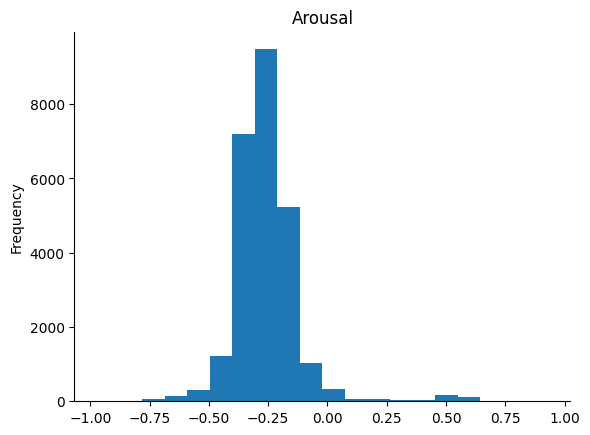

In [14]:
from matplotlib import pyplot as plt
df_2['Arousal'].plot(kind='hist', bins=20, title='Arousal')
plt.gca().spines[['top', 'right',]].set_visible(False)

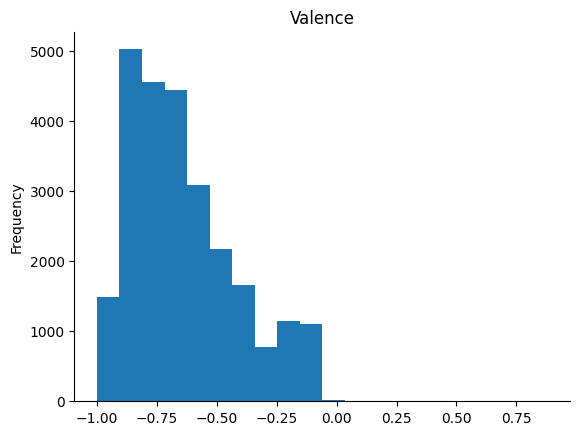

In [15]:
df_2['Valence'].plot(kind='hist', bins=20, title='Valence')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [16]:
df_2.head()

,Image,Arousal,Valence
0,/content/preprocessed_images/275389.npy,-0.380952,-0.714286
1,/content/preprocessed_images/344739.npy,-0.301587,-0.253968
2,/content/preprocessed_images/284330.npy,-0.329075,-0.687185
3,/content/preprocessed_images/331905.npy,-0.380952,-0.412698
4,/content/preprocessed_images/121073.npy,-0.293651,-0.484127


**Regression Model**

In [17]:
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

def define_mtl_va_model(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # Shared Feature Extraction
    x = Conv2D(64, (7,7), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.3)(x)

    x = Conv2D(256, (1,1), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)

    x = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)

    # Task-Specific Layers
    valence_branch = Dense(256, activation='relu', kernel_initializer='he_uniform',
                           kernel_regularizer=regularizers.l2(0.001))(x)
    valence_branch = BatchNormalization()(valence_branch)
    valence_branch = Dropout(0.5)(valence_branch)
    valence_output = Dense(1, activation='linear', name='valence')(valence_branch)

    arousal_branch = Dense(256, activation='relu', kernel_initializer='he_uniform',
                           kernel_regularizer=regularizers.l2(0.001))(x)
    arousal_branch = BatchNormalization()(arousal_branch)
    arousal_branch = Dropout(0.5)(arousal_branch)
    arousal_output = Dense(1, activation='linear', name='arousal')(arousal_branch)

    # Define Model with Two Outputs
    model = Model(inputs=inputs, outputs=[valence_output, arousal_output])

    return model


In [ ]:
model = define_mtl_va_model(input_shape=(224, 224, 3))

In [ ]:
import cv2
import numpy as np
import os

# Convert JPG images to NPY format
for img_path in df_2_val["Image"]:
    img = cv2.imread(img_path)  # Read image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = cv2.resize(img, (224, 224))  # Resize
    img = img.astype(np.float32) / 255.0  # Normalize

    npy_path = img_path.replace(".jpg", ".npy")  # Save as .npy
    np.save(npy_path, img)

    # Update dataset path to the new .npy file
    df_2_val["Image"] = df_2_val["Image"].replace(img_path, npy_path)

# Save the updated CSV file
df_2_val.to_csv("df_2_val_updated.csv", index=False)


In [ ]:
df_2_val.head()

In [ ]:
def load_and_preprocess(img_path, valence, arousal):
    def _load_npy(path):
        path = path.numpy().decode("utf-8")  # Convert Tensor to string
        img = np.load(path)  # Load .npy image
        img = cv2.resize(img, (224, 224))  # Resize

        # Ensure image has 3 channels
        if len(img.shape) == 2:  # Grayscale image
            img = np.stack([img] * 3, axis=-1)  # Convert to 3-channel format
        elif img.shape[-1] != 3:  # Incorrect channel count
            img = img[:, :, :3]  # Keep only first 3 channels if needed

        img = img / 255.0  # Normalize
        return img.astype(np.float32)

    img = tf.py_function(func=_load_npy, inp=[img_path], Tout=tf.float32)

    # 🚀 Explicitly set shape to avoid TensorFlow shape errors
    img.set_shape((224, 224, 3))

    return img, {"valence": tf.reshape(valence, [1]), "arousal": tf.reshape(arousal, [1])}


In [ ]:
# Convert DataFrame columns to a list
image_paths = df_2["Image"].tolist()
valence_values = df_2["Valence"].tolist()
arousal_values = df_2["Arousal"].tolist()

In [ ]:
# Create Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((image_paths, valence_values, arousal_values))
train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Extract validation image paths and labels
val_image_paths = df_2_val["Image"].values  # Paths to validation .npy files
val_valence_labels = df_2_val["Valence"].values.astype(np.float32)
val_arousal_labels = df_2_val["Arousal"].values.astype(np.float32)

In [ ]:
val_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_valence_labels, val_arousal_labels))
val_dataset = val_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss={'valence': 'mse', 'arousal': 'mse'},
              metrics={'valence': 'mae', 'arousal': 'mae'})

In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)